# Start

## Packages

In [2]:
import spatialdata as spd
import spatialdata_plot as splt
import spatialdata_io as so
import geosketch as sketch
import numpy as np
import pandas as pd
import scanpy as sc
import scanpy.external as sce

import json
import gc
import geopandas as gpd
from spatialdata.models import Image2DModel, TableModel, ShapesModel
import matplotlib.pyplot as plt

from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
from PIL import Image
from spatialdata.transformations import Identity, Scale
from shapely.geometry import Polygon

/Users/janzules/miniforge3/envs/vishd_10x/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/janzules/miniforge3/envs/vishd_10x/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/janzules/miniforge3/envs/vishd_10x/lib/python3.11/site-packages/anndata/__init__.py:44: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  return module_

In [3]:
from pathlib import Path
import gc
import numpy as np
import pandas as pd

# Spatial stack
import spatialdata as spd
from spatialdata import polygon_query
from spatialdata.models import ShapesModel
from spatialdata.transformations import Identity
# pip install napari-spatialdata if you don't have it yet
from napari_spatialdata import Interactive

# Plotting (optional)
import matplotlib.pyplot as plt

## Functions

In [4]:
def make_sample_sdata(concat_sdata: spd.SpatialData, sample: str) -> spd.SpatialData:
    """
    Returns a SpatialData with:
      - the image for `sample`
      - the shapes for `sample` (cell boundaries)
      - the global table (segmentation_counts) unchanged

    We detect elements by the naming convention written in create_zarr():
        image  -> f"{sample}_hires_tissue_image"
        shapes -> f"{sample}_cell_boundaries"
    """
    img_key   = f"{sample}_hires_tissue_image"
    shp_key   = f"{sample}_cell_boundaries"

    # Basic guards
    assert img_key in concat_sdata.images,  f"Missing image: {img_key}"
    assert shp_key in concat_sdata.shapes,  f"Missing shapes: {shp_key}"
    assert TABLE_KEY in concat_sdata.tables, "Missing table"

    # Build a slim SpatialData (elements are views of the original)
    sub = spd.SpatialData(
        images = {img_key: concat_sdata.images[img_key]},
        shapes = {shp_key: concat_sdata.shapes[shp_key]},
        tables = {TABLE_KEY: concat_sdata.tables[TABLE_KEY]}
    )
    return sub


In [5]:
def crop0(x,crs,bbox):
    return spd.bounding_box_query(
        x,
        min_coordinate=[bbox['x'][0], bbox['y'][0]],
        max_coordinate=[bbox['x'][1], bbox['y'][1]],
        axes=("x", "y"),
        target_coordinate_system=crs,
    )

# Loading data

In [6]:
# Paths
zarr_folder = Path("/Users/janzules/Roselab/Spatial/CAR_T/data/zarrFiles")
concat_out  = zarr_folder / "concatenated_sdata"  # you already wrote this
annot_out   = zarr_folder / "concatenated_sdata_annotated"  # new output with tissue labels

# Load concatenated SpatialData
sdata = spd.read_zarr(concat_out)

# Constants
TABLE_KEY = "segmentation_counts"   # created by your create_zarr() helper
CRS       = "downscale_to_hires"    # the coordinate system used for images & shapes

version mismatch: detected: RasterFormatV02, requested: FormatV04
/Users/janzules/miniforge3/envs/vishd_10x/lib/python3.11/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
version mismatch: detected: RasterFormatV02, requested: FormatV04
version mismatch: detected: RasterFormatV02, requested: FormatV04
version mismatch: detected: RasterFormatV02, requested: FormatV04


In [7]:
print(sdata)

print("\nImages:", list(sdata.images.keys()))
print("Shapes:", list(sdata.shapes.keys()))
print("Tables:", list(sdata.tables.keys()))

adata = sdata[TABLE_KEY]
assert adata.obs.index.is_unique, "Expected unique obs names"
print("\nObs columns:", adata.obs.columns.tolist())
print("N cells:", adata.n_obs)
print("Unique samples in table:", adata.obs["sample"].unique())


SpatialData object, with associated Zarr store: /Users/janzules/Roselab/Spatial/CAR_T/data/zarrFiles/concatenated_sdata
├── Images
│     ├── 'F07839_hires_tissue_image': DataArray[cyx] (3, 6000, 5227)
│     ├── 'F07840_hires_tissue_image': DataArray[cyx] (3, 6000, 5928)
│     ├── 'F08542_hires_tissue_image': DataArray[cyx] (3, 5954, 6000)
│     └── 'F08543_hires_tissue_image': DataArray[cyx] (3, 5652, 6000)
├── Shapes
│     ├── 'F07839_cell_boundaries': GeoDataFrame shape: (178991, 2) (2D shapes)
│     ├── 'F07840_cell_boundaries': GeoDataFrame shape: (124891, 2) (2D shapes)
│     ├── 'F08542_cell_boundaries': GeoDataFrame shape: (66043, 2) (2D shapes)
│     └── 'F08543_cell_boundaries': GeoDataFrame shape: (58897, 2) (2D shapes)
└── Tables
      └── 'segmentation_counts': AnnData (428822, 19059)
with coordinate systems:
    ▸ 'downscale_to_hires', with elements:
        F07839_hires_tissue_image (Images), F07840_hires_tissue_image (Images), F08542_hires_tissue_image (Images), F08543_h

# Napari

In [8]:
# Choose the TMA/sample you want to annotate
sample_id = "F07840"  # <-- change per TMA

sub_sdata = make_sample_sdata(sdata, sample_id)

/Users/janzules/miniforge3/envs/vishd_10x/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:184: UserWarning: The table is annotating 'F07839_cell_boundaries', which is not present in the SpatialData object.
  self.validate_table_in_spatialdata(v)
/Users/janzules/miniforge3/envs/vishd_10x/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:184: UserWarning: The table is annotating 'F08542_cell_boundaries', which is not present in the SpatialData object.
  self.validate_table_in_spatialdata(v)
/Users/janzules/miniforge3/envs/vishd_10x/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:184: UserWarning: The table is annotating 'F08543_cell_boundaries', which is not present in the SpatialData object.
  self.validate_table_in_spatialdata(v)


In [26]:
from qtpy.QtWidgets import QApplication
from napari_spatialdata import Interactive

app = QApplication.instance() or QApplication([])
viewer = Interactive(sub_sdata)

app.exec()  # blocks until you close the napari window

2025-10-30 21:07:48.817 | WARNING  | napari_spatialdata._viewer:__init__:57 - Due to Shift-L being used as shortcut in napari, it is being deprecated and might not link a new layer to an existing SpatialData object in the viewer. Please use ⌘-L on MacOS or else Ctrl-L.
/Users/janzules/miniforge3/envs/vishd_10x/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
2025-10-30 21:08:05.039 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.
2025-10-30 21:08:05.039 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.
2025-10-30 21:08:06.754 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.
2025-10-30 21:08:06.756 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.
2025-10-30 21:08:31.569 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.
2025-10-30 21:08:31.571 | DEBUG    | napari_

INFO: Layer(s) inherited info from F07840_hires_tissue_image
INFO: Layer saved


2025-10-30 21:10:11.980 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.
2025-10-30 21:10:11.983 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.
2025-10-30 21:11:05.943 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.
2025-10-30 21:11:05.946 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.
2025-10-30 21:11:41.956 | WARNING  | napari_spatialdata._viewer:_write_element_to_disk:178 - Annotations only added in memory, please manually save to disk.


INFO: Layer(s) inherited info from F07840_hires_tissue_image
INFO: Layer saved


2025-10-30 21:12:23.346 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.
2025-10-30 21:12:23.354 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.
2025-10-30 21:12:29.062 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.
2025-10-30 21:12:29.069 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.
2025-10-30 21:12:34.451 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.
2025-10-30 21:12:34.458 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.
2025-10-30 21:12:34.904 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.
2025-10-30 21:12:34.911 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.
2025-10-30 21:12:40.525 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.
2025-10-30 21:12:40.530 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updati

INFO: Layer(s) inherited info from F07840_hires_tissue_image
INFO: Layer saved


0

In [49]:
sub_sdata

SpatialData object
├── Images
│     └── 'F07840_hires_tissue_image': DataArray[cyx] (3, 6000, 5928)
├── Shapes
│     ├── 'CyPSCA_1_2': GeoDataFrame shape: (1, 1) (2D shapes)
│     ├── 'CyT72_1_4': GeoDataFrame shape: (1, 1) (2D shapes)
│     ├── 'F07840_cell_boundaries': GeoDataFrame shape: (124891, 2) (2D shapes)
│     ├── 'RTCyPSCA_2_4': GeoDataFrame shape: (1, 1) (2D shapes)
│     └── 'RTCyT72_2_4': GeoDataFrame shape: (1, 1) (2D shapes)
└── Tables
      └── 'segmentation_counts': AnnData (428822, 19059)
with coordinate systems:
    ▸ 'downscale_to_hires', with elements:
        F07840_hires_tissue_image (Images), CyPSCA_1_2 (Shapes), CyT72_1_4 (Shapes), F07840_cell_boundaries (Shapes), RTCyPSCA_2_4 (Shapes), RTCyT72_2_4 (Shapes)

In [48]:
list(sub_sdata.shapes)

['F07840_cell_boundaries',
 'RTCyT72_2_4',
 'CyT72_1_4',
 'RTCyPSCA_2_4',
 'CyPSCA_1_2']

In [45]:
list(sub_sdata.shapes)

['F07840_cell_boundaries',
 'RTCyT72_2_4',
 'CyT72_1_4',
 'RTCyPSCA_2_4',
 'CyPSCA_1_2']

In [ ]:
from spatialdata import polygon_query

filtered_tables = {}
for shape in ["RTCyT72_2_4", "my_shapes", "my_shapes_2"]:
    polygon = visium_sdata[shape].geometry.iloc[0]
    filtered_tables[shape] = polygon_query(visium_sdata, polygon=polygon, target_coordinate_system="aligned")["table"]

## Re-evaluating approach

In [54]:
from pathlib import Path
import pandas as pd
from spatialdata import polygon_query

TABLE_KEY = "segmentation_counts"
CRS       = "downscale_to_hires"

sample_id = "F07840"  # TMA you're labeling now
polygon_layers = ["CyPSCA_1_2", "CyT72_1_4", "RTCyPSCA_2_4", "RTCyT72_2_4"]

# sanity: polygons + cell boundaries + image exist and share the CRS
print("Polygons present:", all(k in sub_sdata.shapes for k in polygon_layers))
print("Table present:", TABLE_KEY in sub_sdata.tables)
print("Image present:", f"{sample_id}_hires_tissue_image" in sub_sdata.images)
print("Cell boundaries present:", f"{sample_id}_cell_boundaries" in sub_sdata.shapes)
print("OK to proceed.")


Polygons present: True
Table present: True
Image present: True
Cell boundaries present: True
OK to proceed.


In [72]:
sub_sdata['segmentation_counts']

AnnData object with n_obs × n_vars = 428822 × 19059
    obs: 'sample', 'cell_id', 'region', 'tissue'
    uns: 'spatialdata_attrs'

In [73]:
sub_sdata['segmentation_counts'].obs['region']

F07839_cellid_000000001-1    F07839_cell_boundaries
F07839_cellid_000000002-1    F07839_cell_boundaries
F07839_cellid_000000004-1    F07839_cell_boundaries
F07839_cellid_000000005-1    F07839_cell_boundaries
F07839_cellid_000000006-1    F07839_cell_boundaries
                                      ...          
F08543_cellid_000070488-1    F08543_cell_boundaries
F08543_cellid_000070489-1    F08543_cell_boundaries
F08543_cellid_000070490-1    F08543_cell_boundaries
F08543_cellid_000070491-1    F08543_cell_boundaries
F08543_cellid_000070492-1    F08543_cell_boundaries
Name: region, Length: 428822, dtype: category
Categories (4, object): ['F07839_cell_boundaries', 'F07840_cell_boundaries', 'F08542_cell_boundaries', 'F08543_cell_boundaries']

In [75]:
type(sub_sdata)

spatialdata._core.spatialdata.SpatialData

In [74]:
sub_sdata['F07840_cell_boundaries']

,cell_id,geometry
F07840_cellid_000000001-1,F07840_cellid_000000001-1,"POLYGON ((3785.4 3891.2, 3785.4 3894.1, 3788.3..."
F07840_cellid_000000002-1,F07840_cellid_000000002-1,"POLYGON ((5882.8 4463.3, 5882.8 4466.2, 5888.6..."
F07840_cellid_000000003-1,F07840_cellid_000000003-1,"POLYGON ((3889.4 4595.7, 3889.4 4601.5, 3886.5..."
F07840_cellid_000000004-1,F07840_cellid_000000004-1,"POLYGON ((4929.8 4243.2, 4929.7 4246.1, 4935.6..."
F07840_cellid_000000005-1,F07840_cellid_000000005-1,"POLYGON ((4505.2 5355.2, 4505.2 5358.1, 4519.7..."
...,...,...
F07840_cellid_000151391-1,F07840_cellid_000151391-1,"POLYGON ((9927.3 11701.3, 9927.3 11704.2, 9930..."
F07840_cellid_000151392-1,F07840_cellid_000151392-1,"POLYGON ((11323.8 12258.3, 11323.7 12261.2, 11..."
F07840_cellid_000151393-1,F07840_cellid_000151393-1,"POLYGON ((10736.8 11560, 10736.8 11562.9, 1073..."
F07840_cellid_000151394-1,F07840_cellid_000151394-1,"POLYGON ((11729.4 11440, 11729.4 11442.9, 1173..."


In [67]:
sdata

SpatialData object, with associated Zarr store: /Users/janzules/Roselab/Spatial/CAR_T/data/zarrFiles/concatenated_sdata
├── Images
│     ├── 'F07839_hires_tissue_image': DataArray[cyx] (3, 6000, 5227)
│     ├── 'F07840_hires_tissue_image': DataArray[cyx] (3, 6000, 5928)
│     ├── 'F08542_hires_tissue_image': DataArray[cyx] (3, 5954, 6000)
│     └── 'F08543_hires_tissue_image': DataArray[cyx] (3, 5652, 6000)
├── Shapes
│     ├── 'F07839_cell_boundaries': GeoDataFrame shape: (178991, 2) (2D shapes)
│     ├── 'F07840_cell_boundaries': GeoDataFrame shape: (124891, 2) (2D shapes)
│     ├── 'F08542_cell_boundaries': GeoDataFrame shape: (66043, 2) (2D shapes)
│     └── 'F08543_cell_boundaries': GeoDataFrame shape: (58897, 2) (2D shapes)
└── Tables
      └── 'segmentation_counts': AnnData (428822, 19059)
with coordinate systems:
    ▸ 'downscale_to_hires', with elements:
        F07839_hires_tissue_image (Images), F07840_hires_tissue_image (Images), F08542_hires_tissue_image (Images), F08543_h

## testing

### Plotting pebbles

In [79]:
sub_sdata['F07840_hires_tissue_image']

<xarray.DataArray 'image' (c: 3, y: 6000, x: 5928)> Size: 107MB
dask.array<from-zarr, shape=(3, 6000, 5928), dtype=uint8, chunksize=(3, 6000, 5928), chunktype=numpy.ndarray>
Coordinates:
  * c        (c) int64 24B 0 1 2
  * y        (y) float64 48kB 0.5 1.5 2.5 3.5 ... 5.998e+03 5.998e+03 6e+03
  * x        (x) float64 47kB 0.5 1.5 2.5 3.5 ... 5.926e+03 5.926e+03 5.928e+03
Attributes:
    transform:  {'downscale_to_hires': Identity }

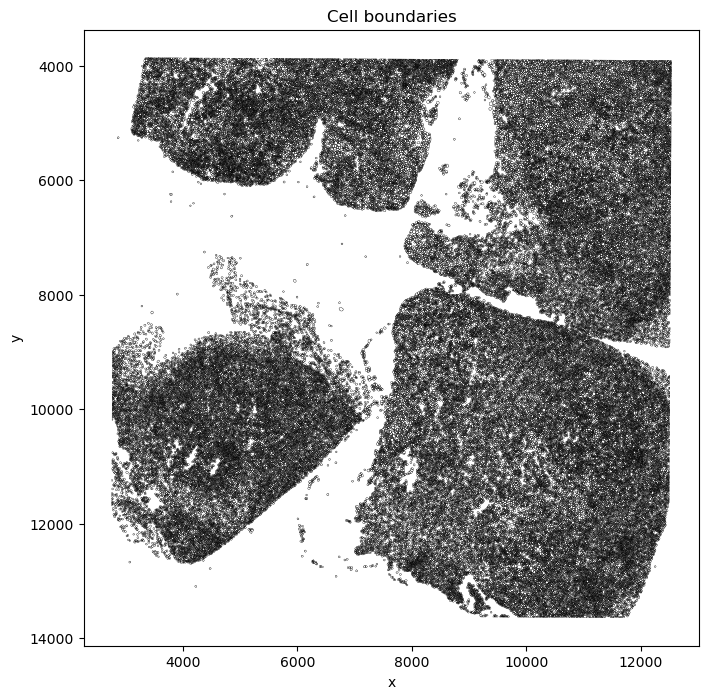

In [78]:
import os

# Your existing plot code
import matplotlib.pyplot as plt
gdf = sub_sdata['F07840_cell_boundaries']

ax = gdf.plot(
    figsize=(8, 8),
    linewidth=0.2,
    edgecolor='black',
    facecolor='none'
)
ax.set_aspect('equal')
ax.invert_yaxis()
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Cell boundaries')

# ---- Save here ----
out_dir = "/Users/janzules/Roselab/Spatial/CAR_T/figures/zarr_anotations"
os.makedirs(out_dir, exist_ok=True)  # no-op if it already exists

fig = ax.get_figure()
png_path = os.path.join(out_dir, "F07840_cell_boundaries.png")
svg_path = os.path.join(out_dir, "F07840_cell_boundaries.svg")  # nice for vector graphics

fig.savefig(png_path, dpi=600, bbox_inches='tight')
fig.savefig(svg_path, bbox_inches='tight')  # vector, scalable

# (optional) only show after saving
plt.show()


In [51]:
crs = "downscale_to_hires"
print("CRS on polygons:")
for name in ["CyPSCA_1_2", "CyT72_1_4", "RTCyPSCA_2_4", "RTCyT72_2_4"]:
    print(name, sub_sdata.shapes[name].attrs.get("transform"))

CRS on polygons:
CyPSCA_1_2 {'downscale_to_hires': Identity }
CyT72_1_4 {'downscale_to_hires': Identity }
RTCyPSCA_2_4 {'downscale_to_hires': Identity }
RTCyT72_2_4 {'downscale_to_hires': Identity }


In [52]:
adata = sdata[TABLE_KEY]
if "tissue" not in adata.obs:
    adata.obs["tissue"] = pd.Categorical(["unassigned"] * adata.n_obs)

# Visual check

Plotting: F07840_hires_tissue_image
INFO     Rasterizing image for faster rendering.                                                                   
INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' to disable this    
         behaviour.                                                                                                


/Users/janzules/miniforge3/envs/vishd_10x/lib/python3.11/site-packages/spatialdata/_core/_elements.py:105: UserWarning: Key `F07840_cell_boundaries` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/Users/janzules/miniforge3/envs/vishd_10x/lib/python3.11/site-packages/spatialdata/_core/_elements.py:125: UserWarning: Key `segmentation_counts` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)


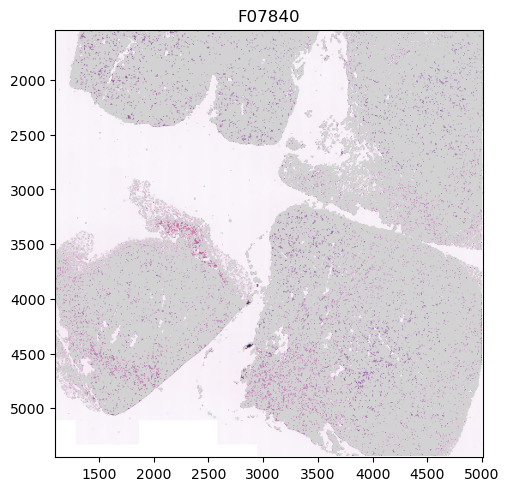

In [9]:
image_elements = list(sub_sdata.images.keys())
shape_elements = list(sub_sdata.shapes.keys())

# We are going to create a bounding box to crop the data to the capture area.
extents = []

for i in range(len(image_elements)):
    extent =  spd.get_extent(sub_sdata,elements=[shape_elements[i]],coordinate_system='downscale_to_hires')
    extents.append(extent)

# Plotting
if len(image_elements) != len(shape_elements):
    print("Check the spatial data to make sure that for every image there is a shape")
else:
    for i in range(len(image_elements)):
        print("Plotting: "+ image_elements[i])
        title=image_elements[i].replace("_hires_tissue_image","")
        crop0(sub_sdata,crs="downscale_to_hires",bbox=extents[i]).pl.render_images(image_elements[i]).pl.render_shapes(shape_elements[i],color="clusters").pl.show(coordinate_systems="downscale_to_hires", title=title)


# Old

In [6]:
# Cell 1: list samples present in the concatenated table and pick one
tbl = concatenated_sdata["segmentation_counts"]
samples = tbl.obs["sample"].astype(str).unique().tolist()
print(f"Found {len(samples)} samples:", samples)

# <<< EDIT THIS for the one you want to start with >>>
sample_name = "F07840"  # e.g., "F07839", "F07840", "F08542", "F08543"
# tma_batch_id = "TMA1"   # optional tag if a sample has >1 TMA you’ll annotate


Found 4 samples: ['F07839', 'F07840', 'F08542', 'F08543']


# Centroid cloud

In [31]:
# Cell 2: get shapes for the selected sample and compute centroids
img_key, shp_key, tbl_key = find_keys_for_sample(concatenated_sdata, sample_name)
print("Image key:", img_key)
print("Shapes key:", shp_key)
print("Table key:", tbl_key)

gdf = shapes_to_geodataframe(concatenated_sdata.shapes[shp_key]).copy()
gdf["cx"] = gdf.geometry.centroid.x
gdf["cy"] = gdf.geometry.centroid.y

# restrict to the current sample's cells (indexes are prefixed with sample name)
idx_mask = pd.Index(gdf.index).astype(str).str.startswith(sample_name + "_")
gdf = gdf.loc[idx_mask].copy()
print(f"Centroids prepared for {sample_name}: n={len(gdf):,}")

# We’ll also align to the AnnData table for writing labels later
adata = concatenated_sdata[tbl_key]
ensure_obs_columns(adata, cols=("tma_label","tma_batch"))


Image key: F07840_hires_tissue_image
Shapes key: F07840_cell_boundaries
Table key: segmentation_counts
Centroids prepared for F07840: n=124,891


## Line by line testing

In [27]:
# type(adata), adata.shape
adata.obs.head()
# adata.var.head()
# adata.X  

,sample,cell_id,region,tma_label,tma_batch
F07839_cellid_000000001-1,F07839,F07839_cellid_000000001-1,F07839_cell_boundaries,NaN,NaN
F07839_cellid_000000002-1,F07839,F07839_cellid_000000002-1,F07839_cell_boundaries,NaN,NaN
F07839_cellid_000000004-1,F07839,F07839_cellid_000000004-1,F07839_cell_boundaries,NaN,NaN
F07839_cellid_000000005-1,F07839,F07839_cellid_000000005-1,F07839_cell_boundaries,NaN,NaN
F07839_cellid_000000006-1,F07839,F07839_cellid_000000006-1,F07839_cell_boundaries,NaN,NaN


In [22]:
len(gdf)

124891

In [21]:
# idx_mask = pd.Index(gdf.index).astype(str).str.startswith(sample_name + "_")
pd.Index(gdf.index).astype(str).str.startswith('F07839_')

0